# Portfolio Growth Report

Читает лучшие параметры из `results/grid_search/best_by_target.csv`,  
перезапускает пайплайн и строит кривые роста ($10 000 стартовый капитал).

In [84]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from dataclasses import replace

from sarb.run import RunConfig, load_market_prices, load_run_config, run_unified_pipeline

# ── константы ───────────────────────────────────────────────────────────────
INITIAL_CAPITAL = 10_000.0
BEST_BY_TARGET_PATH = PROJECT_ROOT / "results" / "grid_search" / "best_by_target.csv"

# ── глобальный стиль графиков: белая тема, тёмный текст ─────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.7,
    "grid.alpha": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#CCCCCC",
    "text.color": "#222222",
    "axes.labelcolor": "#333333",
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "axes.titlecolor": "#111111",
    "legend.facecolor": "white",
    "legend.edgecolor": "#DDDDDD",
    "legend.framealpha": 1.0,
    "legend.labelcolor": "#222222",
    "font.size": 10,
    "figure.dpi": 120,
})

# ── яркая палитра для линий на графиках ─────────────────────────────────────
PALETTE = [
    "#1976D2",  # синий
    "#E65100",  # оранжевый
    "#2E7D32",  # зелёный
    "#C2185B",  # малиновый
    "#6A1B9A",  # фиолетовый
    "#00838F",  # бирюзовый
    "#EF6C00",  # янтарный
    "#00695C",  # зелёно-бирюзовый
    "#B71C1C",  # красный
    "#558B2F",  # оливковый
]

# ── стиль таблиц: белый фон, тёмный текст, без заливки ячеек ────────────────
TABLE_STYLES = [
    {"selector": "", "props": [
        ("border-collapse", "collapse"),
        ("font-size", "13px"),
        ("font-family", "Arial, sans-serif"),
        ("width", "100%"),
    ]},
    {"selector": "thead th", "props": [
        ("background-color", "#F0F4F8"),
        ("color", "#1A202C"),
        ("font-weight", "700"),
        ("border-top", "2px solid #CBD5E0"),
        ("border-bottom", "2px solid #CBD5E0"),
        ("padding", "10px 14px"),
        ("white-space", "nowrap"),
        ("text-align", "left"),
    ]},
    {"selector": "tbody td", "props": [
        ("background-color", "white"),
        ("color", "#1A202C"),
        ("border-bottom", "1px solid #E2E8F0"),
        ("padding", "8px 14px"),
        ("text-align", "left"),
    ]},
    {"selector": "tbody th", "props": [
        ("background-color", "white"),
        ("color", "#718096"),
        ("font-weight", "normal"),
        ("border-bottom", "1px solid #E2E8F0"),
        ("border-right", "1px solid #E2E8F0"),
        ("padding", "8px 10px"),
        ("text-align", "right"),
    ]},
    {"selector": "tbody tr:hover td, tbody tr:hover th", "props": [
        ("background-color", "#F7FAFC"),
    ]},
]

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mikhailchekunov/PycharmProjects/replication-portfolio-arbitrage-mvp


## 1. Лучшие параметры из грид-сёрча

In [85]:
best_params = pd.read_csv(BEST_BY_TARGET_PATH)

preview = best_params[[
    "market", "target", "entry_z", "exit_z", "rebalance_frequency",
    "sharpe_ratio", "annualized_return", "max_drawdown", "total_return",
]].copy()
preview.index = range(1, len(preview) + 1)

(
    preview.style
    .format({
        "sharpe_ratio": "{:.3f}",
        "annualized_return": "{:+.1%}",
        "max_drawdown": "{:.1%}",
        "total_return": "{:+.1%}",
    })
    .set_table_styles(TABLE_STYLES)
    .set_caption("Лучшие параметры по таргету (отсортировано по Sharpe)")
)

,market,target,entry_z,exit_z,rebalance_frequency,sharpe_ratio,annualized_return,max_drawdown,total_return
1,crypto,BNB,3.000000,0.000000,24,1.819,+119.0%,-63.2%,+9615.5%
2,crypto,BTC,2.500000,0.000000,72,2.104,+100.0%,-32.5%,+5611.1%
3,crypto,ETH,3.000000,0.000000,72,2.224,+126.4%,-48.7%,+11698.9%
4,crypto,SOL,2.000000,0.000000,24,2.023,+220.2%,-77.2%,+50482.6%
5,crypto,XRP,2.000000,0.250000,24,1.405,+106.2%,-66.8%,+6727.9%
6,russia,AFKS,3.000000,0.000000,5,1.587,+60.5%,-30.9%,+15990.1%
7,russia,AFLT,2.500000,0.000000,5,1.096,+41.5%,-36.9%,+4067.9%
8,russia,CHMF,2.500000,0.250000,21,1.092,+20.7%,-38.7%,+653.8%
9,russia,GAZP,2.000000,0.000000,21,1.463,+56.6%,-27.2%,+12276.0%
10,russia,LKOH,1.000000,0.500000,10,0.865,+19.1%,-30.5%,+553.6%


## 2. Вспомогательные функции

In [86]:
def prepare_prices(market: str, prices: pd.DataFrame) -> pd.DataFrame:
    if market == "russia":
        return prices.dropna(how="any")
    return prices


def resolve_ticker(prices: pd.DataFrame, target: str) -> str:
    if target in prices.columns:
        return target
    alt = target.replace(".", "-")
    if alt in prices.columns:
        return alt
    raise KeyError(f"Target {target!r} not found in prices")


def reconstruct_run_config(row: pd.Series) -> RunConfig:
    base = load_run_config(str(row["market"]))
    return replace(
        base,
        train_window=int(row["train_window"]),
        rebalance_frequency=int(row["rebalance_frequency"]),
        entry_z=float(row["entry_z"]),
        exit_z=float(row["exit_z"]),
    )


def run_best_pipeline(row: pd.Series, prices: pd.DataFrame):
    target = resolve_ticker(prices, str(row["target"]))
    universe = [s.strip() for s in str(row["universe_assets"]).split(",")]
    run_config = reconstruct_run_config(row)
    return run_unified_pipeline(
        prices, target=target, universe=universe, run_config=run_config,
    )


def compute_trade_stats(result) -> dict:
    """Статистика по сделкам: средний результат и % прибыльных (по сделкам, не по барам)."""
    pos = result.backtest.execution_positions.fillna(0.0)
    rets = result.backtest.strategy_returns.fillna(0.0)
    is_active = pos != 0.0
    if not is_active.any():
        return {"avg_trade": 0.0, "trade_hit_rate": 0.0}
    groups = (pos != pos.shift(fill_value=0.0)).cumsum()
    trade_rets = [
        float((1 + grp).prod() - 1)
        for _, grp in rets[is_active].groupby(groups[is_active])
    ]
    if not trade_rets:
        return {"avg_trade": 0.0, "trade_hit_rate": 0.0}
    return {
        "avg_trade": float(np.mean(trade_rets)),
        "trade_hit_rate": float(sum(1 for r in trade_rets if r > 0) / len(trade_rets)),
    }


def format_rebalance(market: str, freq: int) -> str:
    return f"{freq} ч" if market == "crypto" else f"{freq} дн"


def format_universe(universe: tuple, max_show: int = 5) -> str:
    assets = list(universe)
    shown = ", ".join(assets[:max_show])
    if len(assets) > max_show:
        shown += f" (+{len(assets) - max_show})"
    return shown


print("Функции определены.")

Функции определены.


## 3. Прогон пайплайна

⏳ USA / Russia: ~1–2 мин, Crypto: ~5–10 мин (часовые данные).

In [87]:
import time

pipeline_results = {}  # (market, target) -> UnifiedPipelineResult

for market in ["usa", "russia", "crypto"]:
    t0 = time.time()
    print(f"\n{'─'*55}")
    print(f"  {market.upper()} — загрузка цен...")
    raw_prices = load_market_prices(market)
    prices = prepare_prices(market, raw_prices)
    print(f"  Загружено: {prices.shape[0]:,} строк × {prices.shape[1]} активов")

    for _, row in best_params[best_params["market"] == market].iterrows():
        target = row["target"]
        print(f"  [{market}/{target}]... ", end="", flush=True)
        t1 = time.time()
        try:
            result = run_best_pipeline(row, prices)
            pipeline_results[(market, target)] = result
            m = result.backtest.metrics
            print(
                f"Sharpe={m.sharpe_ratio:.3f}  "
                f"Return={m.total_return*100:+.1f}%  "
                f"MDD={m.max_drawdown*100:.1f}%  "
                f"[{time.time()-t1:.1f}s]"
            )
        except Exception as exc:
            print(f"ОШИБКА: {exc}")

    print(f"  {market.upper()} готово за {time.time()-t0:.1f}s")

print(f"\n✓ Итого: {len(pipeline_results)} таргетов обработано.")


───────────────────────────────────────────────────────
  USA — загрузка цен...
  Загружено: 2,514 строк × 142 активов
  [usa/AAPL]... Sharpe=0.830  Return=+479.7%  MDD=-29.0%  [2.6s]
  [usa/AMZN]... Sharpe=0.915  Return=+470.4%  MDD=-28.9%  [0.3s]
  [usa/BRK.B]... Sharpe=1.164  Return=+100.4%  MDD=-4.1%  [1.4s]
  [usa/MSFT]... Sharpe=0.818  Return=+380.1%  MDD=-31.8%  [0.7s]
  [usa/NVDA]... Sharpe=1.244  Return=+4064.7%  MDD=-35.9%  [0.7s]
  USA готово за 6.1s

───────────────────────────────────────────────────────
  RUSSIA — загрузка цен...
  Загружено: 2,959 строк × 26 активов
  [russia/AFKS]... Sharpe=1.587  Return=+15990.1%  MDD=-30.9%  [3.0s]
  [russia/AFLT]... Sharpe=1.096  Return=+4067.9%  MDD=-36.9%  [3.2s]
  [russia/CHMF]... Sharpe=1.092  Return=+653.8%  MDD=-38.7%  [0.9s]
  [russia/GAZP]... Sharpe=1.463  Return=+12276.0%  MDD=-27.2%  [0.8s]
  [russia/LKOH]... Sharpe=0.865  Return=+553.6%  MDD=-30.5%  [1.6s]
  RUSSIA готово за 9.6s

─────────────────────────────────────────

## 4. Функции визуализации

In [88]:
def plot_equity_curves(
    pipeline_results: dict,
    market: str,
    title: str,
    initial_capital: float = INITIAL_CAPITAL,
    figsize: tuple = (14, 6),
) -> plt.Figure:
    items = sorted(
        [(k, v) for k, v in pipeline_results.items() if k[0] == market],
        key=lambda x: -x[1].backtest.metrics.sharpe_ratio,
    )
    if not items:
        print(f"Нет данных для {market}")
        return None

    fig, ax = plt.subplots(figsize=figsize)
    # явно форсируем белый фон на обоих уровнях
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for i, ((mkt, target), result) in enumerate(items):
        equity = result.backtest.equity_curve * initial_capital
        m = result.backtest.metrics
        rc = result.run_config
        label = (
            f"{target}  |  "
            f"Sharpe {m.sharpe_ratio:.2f}  "
            f"Прирост {m.total_return*100:+.0f}%  "
            f"MDD {m.max_drawdown*100:.0f}%  "
            f"z={rc.entry_z}/{rc.exit_z}"
        )
        ax.plot(
            equity.index, equity,
            label=label,
            linewidth=2.0,
            color=PALETTE[i % len(PALETTE)],
        )

    ax.axhline(
        initial_capital, color="#AAAAAA", linestyle="--",
        linewidth=1.2, label=f"Старт ${initial_capital:,.0f}",
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    ax.set_ylabel("Стоимость портфеля ($)", fontsize=10)
    ax.set_xlabel("Дата", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

    legend = ax.legend(
        loc="upper left", fontsize=8.5,
        frameon=True, borderpad=0.8, labelspacing=0.5,
    )
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("#DDDDDD")

    fig.tight_layout()
    return fig

In [89]:
def build_metrics_table(pipeline_results: dict, market: str) -> pd.io.formats.style.Styler:
    rows = []
    for (mkt, target), result in sorted(
        pipeline_results.items(),
        key=lambda x: -x[1].backtest.metrics.sharpe_ratio,
    ):
        if mkt != market:
            continue

        m = result.backtest.metrics
        rc = result.run_config
        equity = result.backtest.equity_curve * INITIAL_CAPITAL
        ts = compute_trade_stats(result)

        rows.append({
            "Актив": target,
            "Стартовый капитал": INITIAL_CAPITAL,
            "Финальный капитал": equity.iloc[-1],
            "Общий прирост": m.total_return,
            "Среднегеометрический годовой прирост": m.annualized_return,
            "Количество сделок": m.number_of_trades,
            "Средний результат по сделке": ts["avg_trade"],
            "Процент прибыльных сделок": ts["trade_hit_rate"],
            "Максимальная просадка": m.max_drawdown,
            "Коэффициент Шарпа": m.sharpe_ratio,
            "z-score (вход/выход)": f"{rc.entry_z} / {rc.exit_z}",
            "Состав репликативного портфеля": format_universe(result.universe),
        })

    df = pd.DataFrame(rows)
    df.index = range(1, len(df) + 1)

    return (
        df.style
        .format({
            "Стартовый капитал": "${:,.0f}",
            "Финальный капитал": "${:,.0f}",
            "Общий прирост": "{:+.1%}",
            "Среднегеометрический годовой прирост": "{:+.1%}",
            "Средний результат по сделке": "{:+.2%}",
            "Процент прибыльных сделок": "{:.1%}",
            "Максимальная просадка": "{:.1%}",
            "Коэффициент Шарпа": "{:.3f}",
        })
        .set_table_styles(TABLE_STYLES)
    )

---
## 5. США (USA Market)

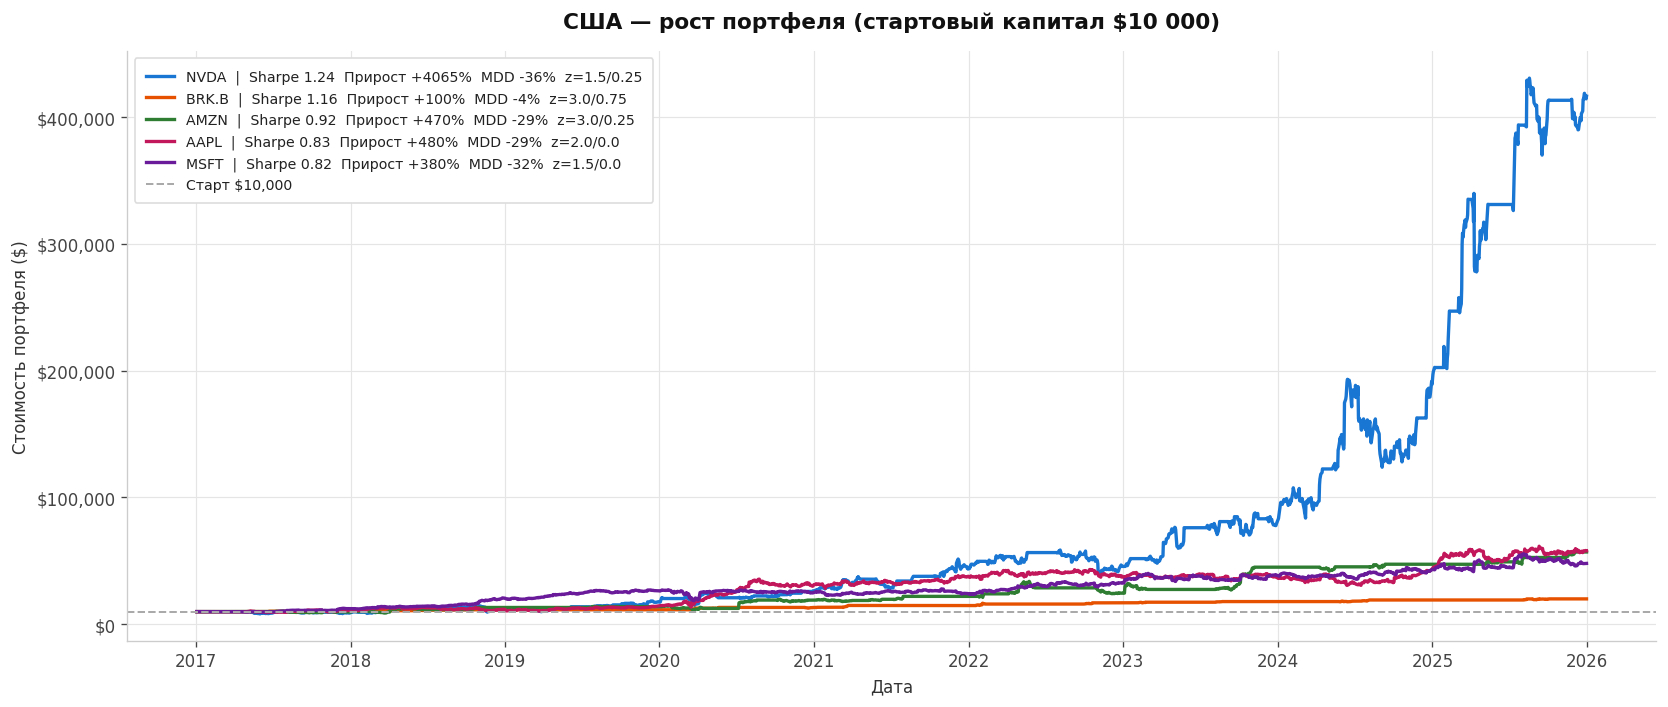

In [90]:
fig = plot_equity_curves(
    pipeline_results, "usa",
    "США — рост портфеля (стартовый капитал $10 000)",
)
plt.show()

In [91]:
build_metrics_table(pipeline_results, "usa")

,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход),Состав репликативного портфеля
1,NVDA,"$10,000","$416,468",+4064.7%,+51.5%,105,+6.90%,78.3%,-35.9%,1.244,1.5 / 0.25,"AAPL, MSFT, AVGO, ORCL, AMD (+25)"
2,BRK.B,"$10,000","$20,041",+100.4%,+8.1%,32,+4.54%,100.0%,-4.1%,1.164,3.0 / 0.75,"NVDA, AAPL, MSFT, AVGO, ORCL (+25)"
3,AMZN,"$10,000","$57,042",+470.4%,+21.4%,41,+8.84%,77.3%,-28.9%,0.915,3.0 / 0.25,"NVDA, AAPL, MSFT, AVGO, ORCL (+25)"
4,AAPL,"$10,000","$57,965",+479.7%,+21.6%,31,+6.12%,80.6%,-29.0%,0.830,2.0 / 0.0,"NVDA, MSFT, AVGO, ORCL, AMD (+25)"
5,MSFT,"$10,000","$48,010",+380.1%,+19.1%,40,+4.08%,85.0%,-31.8%,0.818,1.5 / 0.0,"NVDA, AAPL, AVGO, ORCL, AMD (+25)"


---
## 6. Россия (Russia Market)

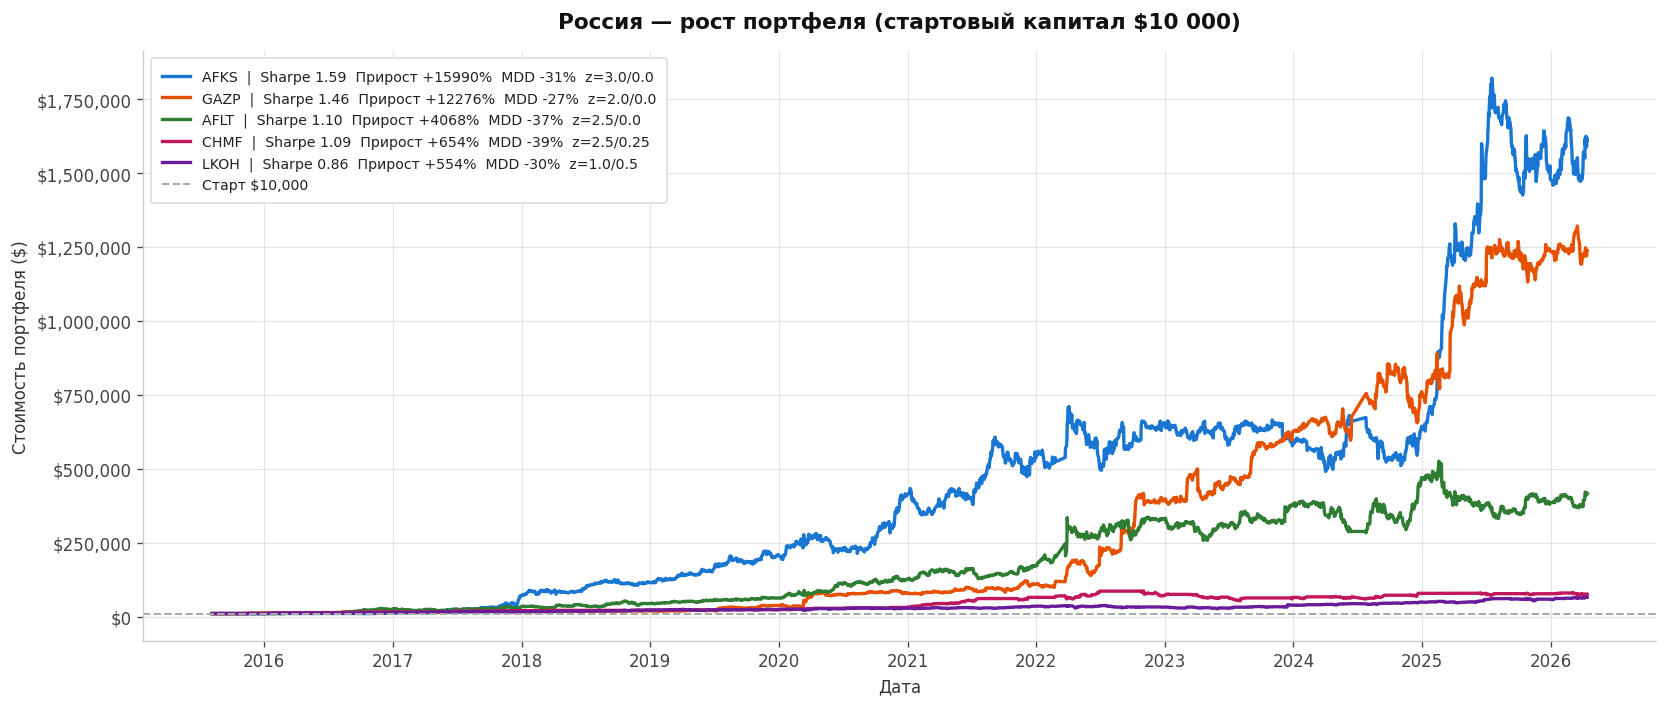

In [92]:
fig = plot_equity_curves(
    pipeline_results, "russia",
    "Россия — рост портфеля (стартовый капитал $10 000)",
)
plt.show()

In [93]:
build_metrics_table(pipeline_results, "russia")

,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход),Состав репликативного портфеля
1,AFKS,"$10,000","$1,609,005",+15990.1%,+60.5%,21,+28.87%,95.2%,-30.9%,1.587,3.0 / 0.0,"AFLT, ALRS, CHMF, GAZP, GMKN (+20)"
2,GAZP,"$10,000","$1,237,604",+12276.0%,+56.6%,40,+13.37%,90.0%,-27.2%,1.463,2.0 / 0.0,"AFKS, AFLT, ALRS, CHMF, GMKN (+20)"
3,AFLT,"$10,000","$416,795",+4067.9%,+41.5%,25,+16.59%,100.0%,-36.9%,1.096,2.5 / 0.0,"AFKS, ALRS, CHMF, GAZP, GMKN (+20)"
4,CHMF,"$10,000","$75,384",+653.8%,+20.7%,70,+5.86%,81.6%,-38.7%,1.092,2.5 / 0.25,"AFKS, AFLT, ALRS, GAZP, GMKN (+20)"
5,LKOH,"$10,000","$65,364",+553.6%,+19.1%,226,+1.76%,79.7%,-30.5%,0.865,1.0 / 0.5,"AFKS, AFLT, ALRS, CHMF, GAZP (+20)"


---
## 7. Крипто (Crypto Market)

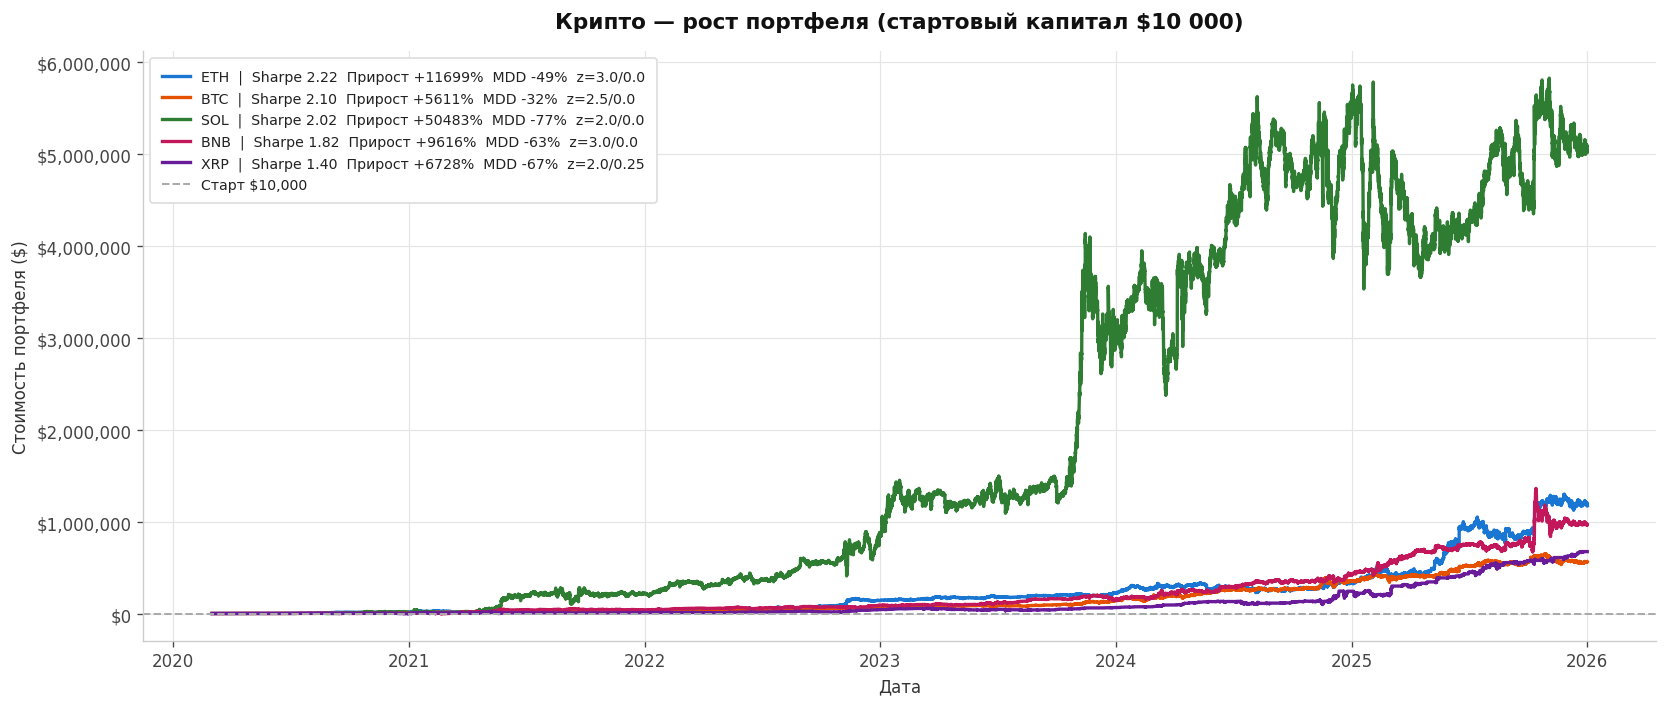

In [94]:
fig = plot_equity_curves(
    pipeline_results, "crypto",
    "Крипто — рост портфеля (стартовый капитал $10 000)",
)
plt.show()

In [95]:
build_metrics_table(pipeline_results, "crypto")

,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход),Состав репликативного портфеля
1,ETH,"$10,000","$1,179,887",+11698.9%,+126.4%,49,+10.57%,89.8%,-48.7%,2.224,3.0 / 0.0,"BTC, SOL, XRP, BNB, TRX (+25)"
2,BTC,"$10,000","$571,114",+5611.1%,+100.0%,84,+5.12%,83.3%,-32.5%,2.104,2.5 / 0.0,"ETH, SOL, XRP, BNB, TRX (+25)"
3,SOL,"$10,000","$5,058,258",+50482.6%,+220.2%,106,+6.82%,73.6%,-77.2%,2.023,2.0 / 0.0,"BTC, ETH, XRP, BNB, TRX (+25)"
4,BNB,"$10,000","$971,551",+9615.5%,+119.0%,51,+9.71%,90.2%,-63.2%,1.819,3.0 / 0.0,"BTC, ETH, SOL, XRP, TRX (+25)"
5,XRP,"$10,000","$682,789",+6727.9%,+106.2%,419,+2.45%,78.5%,-66.8%,1.405,2.0 / 0.25,"BTC, ETH, SOL, BNB, TRX (+25)"


---
## 8. Сводная таблица — все рынки

In [96]:
all_rows = []
for (market, target), result in sorted(
    pipeline_results.items(),
    key=lambda x: (x[0][0], -x[1].backtest.metrics.sharpe_ratio),
):
    m = result.backtest.metrics
    rc = result.run_config
    equity = result.backtest.equity_curve * INITIAL_CAPITAL
    ts = compute_trade_stats(result)

    all_rows.append({
        "Рынок": market.upper(),
        "Актив": target,
        "Стартовый капитал": INITIAL_CAPITAL,
        "Финальный капитал": equity.iloc[-1],
        "Общий прирост": m.total_return,
        "Среднегеометрический годовой прирост": m.annualized_return,
        "Количество сделок": m.number_of_trades,
        "Средний результат по сделке": ts["avg_trade"],
        "Процент прибыльных сделок": ts["trade_hit_rate"],
        "Максимальная просадка": m.max_drawdown,
        "Коэффициент Шарпа": m.sharpe_ratio,
        "z-score (вход/выход)": f"{rc.entry_z} / {rc.exit_z}",
        "Состав репликативного портфеля": format_universe(result.universe),
    })

summary_df = pd.DataFrame(all_rows)
summary_df.index = range(1, len(summary_df) + 1)

(
    summary_df.style
    .format({
        "Стартовый капитал": "${:,.0f}",
        "Финальный капитал": "${:,.0f}",
        "Общий прирост": "{:+.1%}",
        "Среднегеометрический годовой прирост": "{:+.1%}",
        "Средний результат по сделке": "{:+.2%}",
        "Процент прибыльных сделок": "{:.1%}",
        "Максимальная просадка": "{:.1%}",
        "Коэффициент Шарпа": "{:.3f}",
    })
    .set_table_styles(TABLE_STYLES)
    .set_caption("Все рынки и таргеты")
)

,Рынок,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход),Состав репликативного портфеля
1,CRYPTO,ETH,"$10,000","$1,179,887",+11698.9%,+126.4%,49,+10.57%,89.8%,-48.7%,2.224,3.0 / 0.0,"BTC, SOL, XRP, BNB, TRX (+25)"
2,CRYPTO,BTC,"$10,000","$571,114",+5611.1%,+100.0%,84,+5.12%,83.3%,-32.5%,2.104,2.5 / 0.0,"ETH, SOL, XRP, BNB, TRX (+25)"
3,CRYPTO,SOL,"$10,000","$5,058,258",+50482.6%,+220.2%,106,+6.82%,73.6%,-77.2%,2.023,2.0 / 0.0,"BTC, ETH, XRP, BNB, TRX (+25)"
4,CRYPTO,BNB,"$10,000","$971,551",+9615.5%,+119.0%,51,+9.71%,90.2%,-63.2%,1.819,3.0 / 0.0,"BTC, ETH, SOL, XRP, TRX (+25)"
5,CRYPTO,XRP,"$10,000","$682,789",+6727.9%,+106.2%,419,+2.45%,78.5%,-66.8%,1.405,2.0 / 0.25,"BTC, ETH, SOL, BNB, TRX (+25)"
6,RUSSIA,AFKS,"$10,000","$1,609,005",+15990.1%,+60.5%,21,+28.87%,95.2%,-30.9%,1.587,3.0 / 0.0,"AFLT, ALRS, CHMF, GAZP, GMKN (+20)"
7,RUSSIA,GAZP,"$10,000","$1,237,604",+12276.0%,+56.6%,40,+13.37%,90.0%,-27.2%,1.463,2.0 / 0.0,"AFKS, AFLT, ALRS, CHMF, GMKN (+20)"
8,RUSSIA,AFLT,"$10,000","$416,795",+4067.9%,+41.5%,25,+16.59%,100.0%,-36.9%,1.096,2.5 / 0.0,"AFKS, ALRS, CHMF, GAZP, GMKN (+20)"
9,RUSSIA,CHMF,"$10,000","$75,384",+653.8%,+20.7%,70,+5.86%,81.6%,-38.7%,1.092,2.5 / 0.25,"AFKS, AFLT, ALRS, GAZP, GMKN (+20)"
10,RUSSIA,LKOH,"$10,000","$65,364",+553.6%,+19.1%,226,+1.76%,79.7%,-30.5%,0.865,1.0 / 0.5,"AFKS, AFLT, ALRS, CHMF, GAZP (+20)"


---
## 9. Сравнение: лучший таргет с каждого рынка

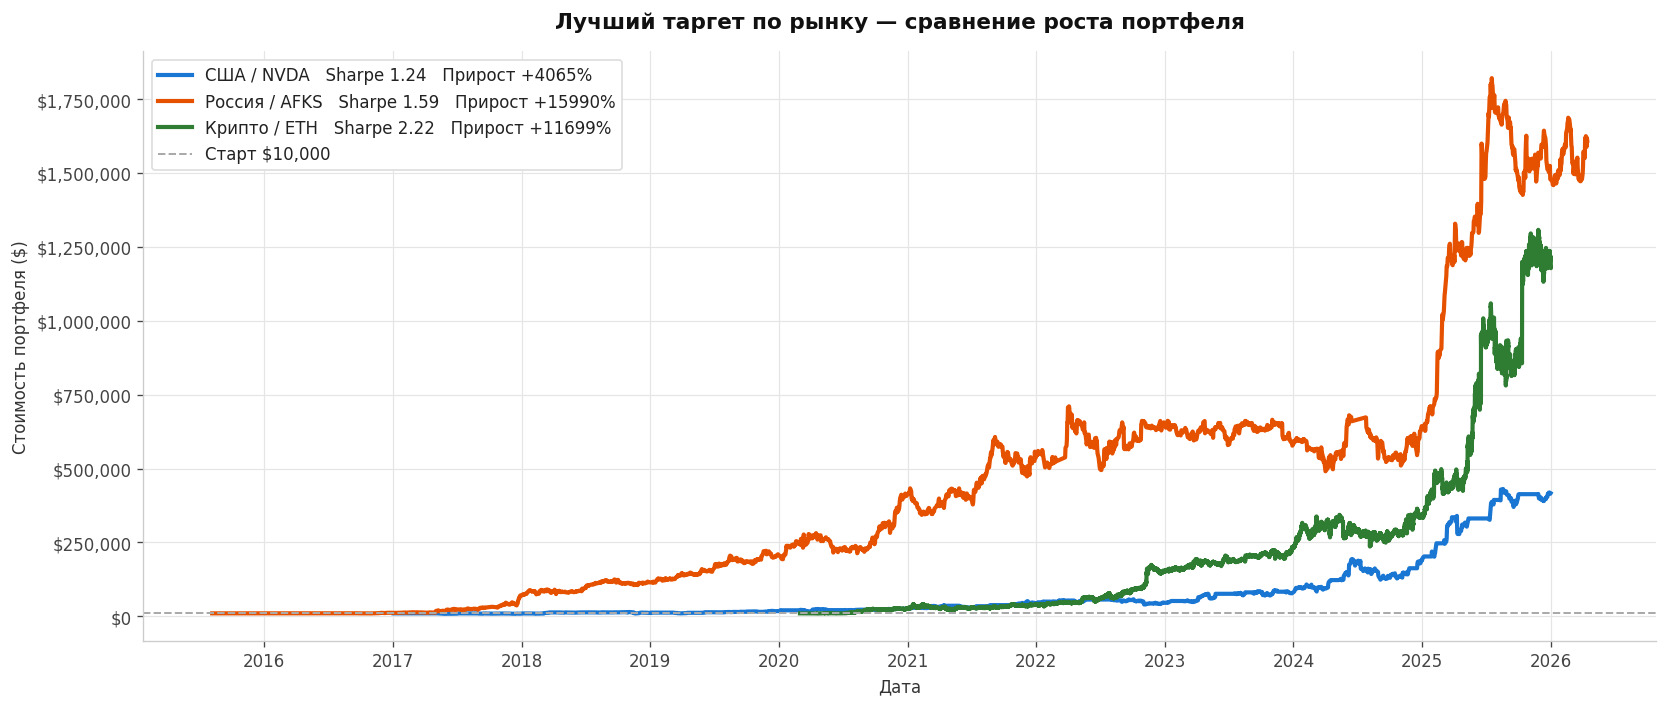

In [97]:
MARKET_COLORS = {"usa": "#1976D2", "russia": "#E65100", "crypto": "#2E7D32"}
MARKET_LABELS = {"usa": "США", "russia": "Россия", "crypto": "Крипто"}

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for market in ["usa", "russia", "crypto"]:
    candidates = [(k, v) for k, v in pipeline_results.items() if k[0] == market]
    if not candidates:
        continue
    (_, target), result = max(candidates, key=lambda x: x[1].backtest.metrics.sharpe_ratio)
    equity = result.backtest.equity_curve * INITIAL_CAPITAL
    m = result.backtest.metrics
    label = (
        f"{MARKET_LABELS[market]} / {target}   "
        f"Sharpe {m.sharpe_ratio:.2f}   "
        f"Прирост {m.total_return*100:+.0f}%"
    )
    ax.plot(
        equity.index, equity,
        label=label, linewidth=2.5,
        color=MARKET_COLORS[market],
    )

ax.axhline(
    INITIAL_CAPITAL, color="#AAAAAA", linestyle="--",
    linewidth=1.2, label=f"Старт ${INITIAL_CAPITAL:,.0f}",
)

ax.set_title(
    "Лучший таргет по рынку — сравнение роста портфеля",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_ylabel("Стоимость портфеля ($)", fontsize=10)
ax.set_xlabel("Дата", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")

legend = ax.legend(fontsize=10, frameon=True)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#DDDDDD")

fig.tight_layout()
plt.show()